In [1]:
import kagglehub

path = kagglehub.dataset_download("rajatkumar30/fake-news")
print("Path to dataset files:", path)


100%|██████████| 11.5M/11.5M [00:01<00:00, 8.00MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rajatkumar30/fake-news/versions/1


In [2]:
import os
os.listdir(path)

['news.csv']

In [3]:
import pandas as pd

df = pd.read_csv(path + "/news.csv")

In [4]:
df.head()


,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [5]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6335 non-null   int64 
 1   title       6335 non-null   object
 2   text        6335 non-null   object
 3   label       6335 non-null   object
dtypes: int64(1), object(3)
memory usage: 198.1+ KB


In [7]:
df = df.drop(columns=['Unnamed: 0'])

In [8]:
df.isnull().sum()

,0
title,0
text,0
label,0


In [9]:
df.duplicated().sum()

np.int64(29)

In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.shape

(6306, 3)

In [13]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

In [14]:
df['clean_text'] = df['text'].apply(clean_text)

In [15]:
df[['text', 'clean_text']].head()

,text,clean_text
0,"Daniel Greenfield, a Shillman Journalism Fello...",daniel greenfield a shillman journalism fellow...
1,Google Pinterest Digg Linkedin Reddit Stumbleu...,google pinterest digg linkedin reddit stumbleu...
2,U.S. Secretary of State John F. Kerry said Mon...,us secretary of state john f kerry said monday...
3,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",kaydee king kaydeeking november the lesson fr...
4,It's primary day in New York and front-runners...,its primary day in new york and frontrunners h...


In [16]:
df.to_csv("cleaned_stage1.csv", index=False)

In [17]:
import nltk
from nltk.corpus import stopwords

# Download stopwords
nltk.download('stopwords')

# Load English stopwords
stop_words = set(stopwords.words('english'))

# Remove stopwords from clean_text
df['no_stopwords'] = df['clean_text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in stop_words])
)

# Check result
df[['clean_text', 'no_stopwords']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,clean_text,no_stopwords
0,daniel greenfield a shillman journalism fellow...,daniel greenfield shillman journalism fellow f...
1,google pinterest digg linkedin reddit stumbleu...,google pinterest digg linkedin reddit stumbleu...
2,us secretary of state john f kerry said monday...,us secretary state john f kerry said monday st...
3,kaydee king kaydeeking november the lesson fr...,kaydee king kaydeeking november lesson tonight...
4,its primary day in new york and frontrunners h...,primary day new york frontrunners hillary clin...


In [18]:
df.to_csv("cleaned_stage2_stopwords.csv", index=False)

In [19]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [20]:
import nltk
from nltk.tokenize import word_tokenize

# Download tokenizer
nltk.download('punkt')

# Tokenize the text after stopword removal
df['tokens'] = df['no_stopwords'].apply(word_tokenize)

# Check result
df[['no_stopwords', 'tokens']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


,no_stopwords,tokens
0,daniel greenfield shillman journalism fellow f...,"[daniel, greenfield, shillman, journalism, fel..."
1,google pinterest digg linkedin reddit stumbleu...,"[google, pinterest, digg, linkedin, reddit, st..."
2,us secretary state john f kerry said monday st...,"[us, secretary, state, john, f, kerry, said, m..."
3,kaydee king kaydeeking november lesson tonight...,"[kaydee, king, kaydeeking, november, lesson, t..."
4,primary day new york frontrunners hillary clin...,"[primary, day, new, york, frontrunners, hillar..."


In [21]:
import nltk
from nltk.stem import WordNetLemmatizer

# Download required data
nltk.download('wordnet')
nltk.download('omw-1.4')

# Create lemmatizer
lemmatizer = WordNetLemmatizer()

# Apply lemmatization on tokenized words
df['lemmatized'] = df['tokens'].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

# Check result
df[['tokens', 'lemmatized']].head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


,tokens,lemmatized
0,"[daniel, greenfield, shillman, journalism, fel...","[daniel, greenfield, shillman, journalism, fel..."
1,"[google, pinterest, digg, linkedin, reddit, st...","[google, pinterest, digg, linkedin, reddit, st..."
2,"[us, secretary, state, john, f, kerry, said, m...","[u, secretary, state, john, f, kerry, said, mo..."
3,"[kaydee, king, kaydeeking, november, lesson, t...","[kaydee, king, kaydeeking, november, lesson, t..."
4,"[primary, day, new, york, frontrunners, hillar...","[primary, day, new, york, frontrunners, hillar..."


In [22]:
df['final_text'] = df['lemmatized'].apply(lambda words: ' '.join(words))

df[['lemmatized', 'final_text']].head()

,lemmatized,final_text
0,"[daniel, greenfield, shillman, journalism, fel...",daniel greenfield shillman journalism fellow f...
1,"[google, pinterest, digg, linkedin, reddit, st...",google pinterest digg linkedin reddit stumbleu...
2,"[u, secretary, state, john, f, kerry, said, mo...",u secretary state john f kerry said monday sto...
3,"[kaydee, king, kaydeeking, november, lesson, t...",kaydee king kaydeeking november lesson tonight...
4,"[primary, day, new, york, frontrunners, hillar...",primary day new york frontrunners hillary clin...


In [23]:
comparison_df = df[['text', 'clean_text', 'no_stopwords', 'final_text']].head(5)

comparison_df

,text,clean_text,no_stopwords,final_text
0,"Daniel Greenfield, a Shillman Journalism Fello...",daniel greenfield a shillman journalism fellow...,daniel greenfield shillman journalism fellow f...,daniel greenfield shillman journalism fellow f...
1,Google Pinterest Digg Linkedin Reddit Stumbleu...,google pinterest digg linkedin reddit stumbleu...,google pinterest digg linkedin reddit stumbleu...,google pinterest digg linkedin reddit stumbleu...
2,U.S. Secretary of State John F. Kerry said Mon...,us secretary of state john f kerry said monday...,us secretary state john f kerry said monday st...,u secretary state john f kerry said monday sto...
3,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",kaydee king kaydeeking november the lesson fr...,kaydee king kaydeeking november lesson tonight...,kaydee king kaydeeking november lesson tonight...
4,It's primary day in New York and front-runners...,its primary day in new york and frontrunners h...,primary day new york frontrunners hillary clin...,primary day new york frontrunners hillary clin...


In [24]:
for i in range(3):
    print(f"\n--- Sample {i+1} ---")
    print("Original Text:\n", df['text'].iloc[i])
    print("\nAfter Basic Cleaning:\n", df['clean_text'].iloc[i])
    print("\nAfter Stopword Removal:\n", df['no_stopwords'].iloc[i])
    print("\nFinal Preprocessed Text:\n", df['final_text'].iloc[i])
    print("\n" + "="*100)


--- Sample 1 ---
Original Text:
 Daniel Greenfield, a Shillman Journalism Fellow at the Freedom Center, is a New York writer focusing on radical Islam. 
In the final stretch of the election, Hillary Rodham Clinton has gone to war with the FBI. 
The word “unprecedented” has been thrown around so often this election that it ought to be retired. But it’s still unprecedented for the nominee of a major political party to go war with the FBI. 
But that’s exactly what Hillary and her people have done. Coma patients just waking up now and watching an hour of CNN from their hospital beds would assume that FBI Director James Comey is Hillary’s opponent in this election. 
The FBI is under attack by everyone from Obama to CNN. Hillary’s people have circulated a letter attacking Comey. There are currently more media hit pieces lambasting him than targeting Trump. It wouldn’t be too surprising if the Clintons or their allies were to start running attack ads against the FBI. 
The FBI’s leadership is

In [25]:
df.to_csv("fake_news_preprocessed.csv", index=False)

In [26]:
df.columns

Index(['title', 'text', 'label', 'clean_text', 'no_stopwords', 'tokens',
       'lemmatized', 'final_text'],
      dtype='object')

In [27]:
df[['text', 'final_text']].head()

,text,final_text
0,"Daniel Greenfield, a Shillman Journalism Fello...",daniel greenfield shillman journalism fellow f...
1,Google Pinterest Digg Linkedin Reddit Stumbleu...,google pinterest digg linkedin reddit stumbleu...
2,U.S. Secretary of State John F. Kerry said Mon...,u secretary state john f kerry said monday sto...
3,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",kaydee king kaydeeking november lesson tonight...
4,It's primary day in New York and front-runners...,primary day new york frontrunners hillary clin...


In [28]:
df_ml = df[['final_text', 'label']]

In [29]:
df_ml.head()

,final_text,label
0,daniel greenfield shillman journalism fellow f...,FAKE
1,google pinterest digg linkedin reddit stumbleu...,FAKE
2,u secretary state john f kerry said monday sto...,REAL
3,kaydee king kaydeeking november lesson tonight...,FAKE
4,primary day new york frontrunners hillary clin...,REAL


In [30]:
df_ml.to_csv("final_cleaned_data.csv", index=False)

In [31]:
# Neha Jha here...

from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize with n-grams (1, 2)
tfidf_v2 = TfidfVectorizer(stop_words='english', max_df=0.7, ngram_range=(1, 2))

# Transform the text
X_v2 = tfidf_v2.fit_transform(df_ml['final_text'])
y = df_ml['label']

print(f"New Feature matrix shape: {X_v2.shape}")

New Feature matrix shape: (6306, 1509551)


In [32]:
from sklearn.model_selection import train_test_split

# Split using the new X_v2 matrix
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_v2, y, test_size=0.2, random_state=42)

print(f"New Training samples: {X_train2.shape}")

New Training samples: (5044, 1509551)


In [33]:
from sklearn.linear_model import PassiveAggressiveClassifier

# Initialize the model
# max_iter=50 gives it enough passes over the data to learn effectively
pac = PassiveAggressiveClassifier(max_iter=50)

# Train the model
pac.fit(X_train2, y_train2)

print("Passive Aggressive Classifier trained!")

Passive Aggressive Classifier trained!


Final Accuracy: 93.42%
Precision: 0.92
Recall: 0.94


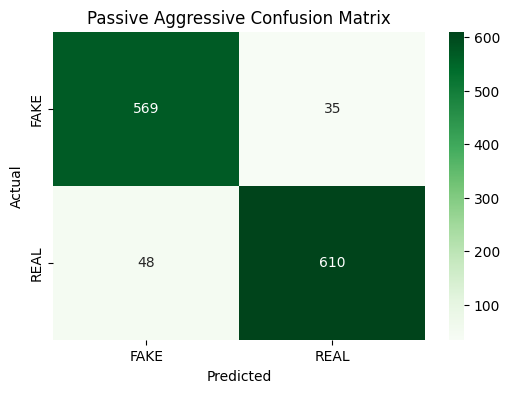

In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Predict on the new test set
y_pred2 = pac.predict(X_test2)

# 2. Calculate New Accuracy
final_accuracy = accuracy_score(y_test2, y_pred2)
print(f"Final Accuracy: {final_accuracy:.2%}")

precision = precision_score(y_test2, y_pred2, pos_label='FAKE')
recall = recall_score(y_test2, y_pred2, pos_label='FAKE')

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

# 3. Plot the New Confusion Matrix
cm2 = confusion_matrix(y_test2, y_pred2)

plt.figure(figsize=(6, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Passive Aggressive Confusion Matrix')
plt.show()

In [36]:
df.groupby('label')['text_length'].agg(['mean', 'min', 'max'])

KeyError: 'Column not found: text_length'

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)
plt.title("Distribution of Fake vs Real News")
plt.xlabel("Label (0 = FAKE, 1 = REAL)")
plt.ylabel("Count")
plt.show()

In [ ]:
df['text_length'] = df['final_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='text_length', data=df)
plt.title("Text Length Distribution (Fake vs Real)")
plt.xlabel("Label")
plt.ylabel("Number of Words")
plt.show()

In [ ]:
!pip install wordcloud

In [ ]:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# ---------------------------
# WordCloud for FAKE news
# ---------------------------
fake_text = " ".join(df[df['label'] == 'FAKE']['final_text'].dropna())

wc_fake = WordCloud(width=800, height=400, background_color='white').generate(fake_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_fake, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud for Fake News")
plt.show()


# ---------------------------
# WordCloud for REAL news
# ---------------------------
real_text = " ".join(df[df['label'] == 'REAL']['final_text'].dropna())

wc_real = WordCloud(width=800, height=400, background_color='white').generate(real_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_real, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud for Real News")
plt.show()

In [ ]:
from collections import Counter
import pandas as pd

# Get top words for FAKE
fake_words = " ".join(df[df['label'] == 'FAKE']['final_text']).split()
fake_common = Counter(fake_words).most_common(10)

fake_df = pd.DataFrame(fake_common, columns=['word', 'count'])

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x='count', y='word', data=fake_df)
plt.title("Top Words in Fake News")
plt.show()


# Get top words for REAL
real_words = " ".join(df[df['label'] == 'REAL']['final_text']).split()
real_common = Counter(real_words).most_common(10)

real_df = pd.DataFrame(real_common, columns=['word', 'count'])

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x='count', y='word', data=real_df)
plt.title("Top Words in Real News")
plt.show()